<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2_ext/01_explore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Analysis with AI: Exploring the Toy Car Data

This notebook is the first of five labs that accompany [Bach, Chernozhukov, Klaassen, Spindler, Teichert-Kluge and Vijaykumar (2025), *Adventures in Demand Analysis Using AI*](https://arxiv.org/abs/2501.00382). Together, the labs estimate the price elasticity of demand for toy cars sold on Amazon.com, using product descriptions and product images as additional sources of information.

In this lab, we introduce the data: product descriptions, product images, and a short panel of prices and sales ranks. We end with a naive regression of quantity on price. As we will see, it yields an estimate that is not economically plausible, which motivates the analysis in the remaining labs.

Labs 3, 4 and 5 use the embeddings produced in Lab 2. This lab does not, so it runs on a CPU.

## Data

The data cover toy cars sold on Amazon.com and were compiled by the data aggregator Keepa.com. For each product, we observe its sales rank and its buy box price over time, together with a product description, an image, and a few tabular attributes. This version of the labs uses the full data set. The published panel files contain 7,549 products (the paper reports $N = 7{,}226$). We split them by product into samples of the same size as in the paper, but draw our own split.

## Measuring Prices and Quantities

Let $i$ index products and $t$ index four-week periods.

**Quantity signal.** Amazon does not publish unit sales, so we use the sales rank as a proxy. Since a higher rank number means fewer units sold, we invert it and define
$$Q_{it} := \log\bigl(1/\text{Time-Averaged Sales Rank of } i \text{ in period } t\bigr).$$
A higher $Q_{it}$ means that the product sells more relative to other products in the category.

**Price signal.** The buy box price is the price shown to a customer who is ready to purchase. We define
$$P_{it} := \log\bigl(\text{Time-Averaged Price of } i \text{ in period } t\bigr).$$

Both signals are in logs, so the coefficient in a regression of $Q$ on $P$ can be read as an elasticity. We also use the changes over time, $\Delta Q_{it} := Q_{it} - Q_{i,t-1}$ and $\Delta P_{it} := P_{it} - P_{i,t-1}$.

**Remark (from rank elasticities to demand elasticities).** The sales rank is not a quantity. If the number of units sold follows a Pareto distribution with shape parameter $\vartheta$, the price elasticity of actual demand is approximately $1/\vartheta$ times the rank elasticity. He and Hollenbeck (2020) estimate $\hat{\vartheta} \approx 0.5$ for toys on Amazon.com, so multiplying a rank elasticity by about 2 gives an approximate demand elasticity. We use this conversion throughout the labs.

We start by loading the required packages.

In [1]:
import io
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from PIL import Image

palette = sns.color_palette("colorblind")
pd.set_option("display.width", 120)

## Constructing the Data Set

The data are stored in the paper's reproduction repository in two parts: a panel of prices, sales ranks, descriptions and tabular attributes (about 42 MB), and the product images, which are split across sixteen parquet part-files of roughly 90 MB each. This lab needs only one image part-file, for the product example below; Lab 2 downloads all sixteen.

We split the data by product. Every product, with all of its periods, belongs to exactly one of two samples: 3,774 products form the fine-tuning sample $I_1$, on which Lab 2 trains the embeddings, and the remaining 3,775 products form the estimation sample $I_2$, on which Labs 4 and 5 estimate elasticities. These are the sample sizes of the paper, but the split itself is a random draw of our own, so the products in each sample differ from the paper's.

The repository also contains the (ASIN, date) keys of the observations the paper keeps once the lagged variables are formed. We use them to select the same rows as the paper; they do not affect which sample a product belongs to.

**Note:** The configuration in the next cell must be identical in Labs 1 and 2. Both notebooks construct the data set from scratch, and since the draw is deterministic, the same configuration yields the same split.

In [2]:
# ---------------------------------------------------------------------------
# Configuration. Keep this cell identical in Labs 1 and 2.
# ---------------------------------------------------------------------------
BASE = ("https://raw.githubusercontent.com/JanTeichertKluge/"
        "demand-analysis-repro/main/main")
SEED = 42

# Products in the fine-tuning sample I_1; all other products form the
# estimation sample I_2.
N_FINETUNE = 3774

# The panel comes in a train and a validation part. We load both and draw our
# own split by product.
PANEL_DIR = "data/amzn_toys_monthly_diffs_ffill_fixed_splits_buybox"
panel_files = [f"{PANEL_DIR}/{part}-0000{k}-of-00002.parquet"
               for part in ("train", "validation") for k in range(2)]

# (ASIN, date) keys of the observations the paper keeps once lags are formed.
# They decide which rows enter the analysis, not which split a product is in.
key_files = ["code/main_train_keys.csv", "code/main_val_keys.csv"]

# All 16 image part-files (about 1.3 GB). Lab 1 downloads only the first one.
IMAGE_DIR = "data/amzn_toys_monthly_avg_long_ffill_28_7_images"
image_files = [f"{IMAGE_DIR}/train-0000{i}-of-00004-part00{j}.parquet"
               for i in range(4) for j in range(4)]


def fetch(remote):
    """Download a file of the reproduction repository once; return the local path."""
    local = "data_cache/" + remote.split("/")[-1]
    if not os.path.exists(local):
        print("downloading", local, flush=True)
        urllib.request.urlretrieve(f"{BASE}/{remote}", local)
    return local


os.makedirs("data_cache", exist_ok=True)
for remote in panel_files + key_files:
    fetch(remote)

print("panel and sample keys ready")

downloading data_cache/train-00000-of-00002.parquet
downloading data_cache/train-00001-of-00002.parquet
downloading data_cache/validation-00000-of-00002.parquet
downloading data_cache/validation-00001-of-00002.parquet
downloading data_cache/main_train_keys.csv
downloading data_cache/main_val_keys.csv
panel and sample keys ready (~42 MB, cached for this session)


Next, we load the panel and construct the data set as in the paper. We keep the 28-day averages at four-week intervals, which gives 14 periods from January 30, 2023 to January 29, 2024. Unlike the subsample version of the labs, we do not require a product to be observed in every period: the panel is unbalanced, and the lagged variables refer to a product's previous observed period, as in the paper's pipeline. We then draw the split by product and flag the rows the paper keeps.

In [3]:
columns = ["ASIN", "window", "date", "SALES_RANK", "BUYBOX_PRICE", "text",
           "RATING", "REVIEW_COUNT", "subcat_aggregated",
           "New Offer Count: Current",
           "Count of retrieved live offers: New, FBA",
           "Count of retrieved live offers: New, FBM",
           "Lightning Deals: Upcoming Deal", "Buy Box: Is FBA"]

panel = pd.concat([pd.read_parquet(fetch(f), columns=columns) for f in panel_files],
                  ignore_index=True)

# Keep the 28-day time averages, then every fourth week: 14 four-week periods
# from 2023-01-30 to 2024-01-29. SALES_RANK is already log(1 / sales rank) and
# BUYBOX_PRICE already log(price), so they are the paper's Q_it and P_it.
# As in the paper, the panel is unbalanced: a product enters with every period
# in which it is observed.
panel = panel[panel["window"] == 28].drop(columns="window").dropna()
dates = np.sort(panel["date"].unique())
panel["date_t"] = panel["date"].map({d: i for i, d in enumerate(dates)})
panel = panel[(panel["date_t"] <= 54) & (panel["date_t"] % 4 == 0)]
panel["period"] = panel["date_t"] // 4
panel = panel.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"})

df = panel.sort_values(["ASIN", "period"]).reset_index(drop=True)

# Deterministic split by product: every product, with all of its periods, is
# in exactly one sample. Labs 4 and 5 estimate only on the "estimation"
# products, so the embeddings they use were fitted on different products. The
# paper's Addendum A relies on that independence.
asins = np.sort(df["ASIN"].unique())
rng = np.random.default_rng(SEED)
finetune = set(rng.choice(asins, size=N_FINETUNE, replace=False))
df["split"] = np.where(df["ASIN"].isin(finetune), "finetune", "estimation")
assert df.groupby("ASIN")["split"].nunique().max() == 1, "a product is in both splits"

# Lagged state and first differences, within product. As in the paper, the lag
# is the product's previous observed period.
grouped = df.groupby("ASIN")
df["Q_t-1"] = grouped["Q_t"].shift(1)
df["P_bb_t-1"] = grouped["P_bb_t"].shift(1)
df["RATING_t-1"] = grouped["RATING"].shift(1)
df["REVIEW_COUNT_t-1"] = grouped["REVIEW_COUNT"].shift(1)
df["Delta_Q_t"] = df["Q_t"] - df["Q_t-1"]
df["Delta_P_bb_t"] = df["P_bb_t"] - df["P_bb_t-1"]

# Flag the rows the paper keeps: every row with a lagged state, minus a few
# that the paper's pipeline dropped. Labs 3 to 5 use only these rows.
keys = pd.concat([pd.read_csv(fetch(f), dtype=str) for f in key_files])
df["in_sample"] = pd.MultiIndex.from_frame(df[["ASIN", "date"]].astype(str)).isin(
    pd.MultiIndex.from_frame(keys[["ASIN", "date"]]))
assert df["in_sample"].sum() == len(keys)

print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size"),
                              in_sample=("in_sample", "sum")))

            products   rows  in_sample
split                                 
estimation      3775  41736      37940
finetune        3774  42041      38247


The panel contains 7,549 products and 83,777 product-periods, split into 3,774 fine-tuning and 3,775 estimation products; 4,529 products are observed in all 14 periods. Dropping the first observation of each product, which has no lagged values, and a few rows that the paper's pipeline also dropped leaves 38,247 observations in the fine-tuning sample and 37,940 in the estimation sample, close to the paper's 38,146 and 38,041. Since the panel is unbalanced, equal numbers of products do not imply equal numbers of rows. Let us look at the first rows of the data.

In [4]:
df[["ASIN", "date", "period", "split", "in_sample", "Q_t", "P_bb_t"]].head()

,ASIN,date,period,split,in_sample,Q_t,P_bb_t
0,1947335162,2023-01-30,0,estimation,False,-12.747395,3.555062
1,1947335162,2023-02-27,1,estimation,True,-12.600586,3.555062
2,1947335162,2023-03-27,2,estimation,True,-12.515369,3.633271
3,1947335162,2023-04-24,3,estimation,True,-12.576837,3.582963
4,1947335162,2023-05-22,4,estimation,True,-12.688608,3.587493


### Variables

| Variable | Description |
|---|---|
| `Q_t` | $\log(1/\text{sales rank})$, the quantity signal |
| `P_bb_t` | $\log(\text{buy box price})$, excluding shipping and handling |
| `REVIEW_COUNT` | Number of reviews |
| `RATING` | Average customer rating |
| `Lightning Deals: Upcoming Deal` | 1 if the product is promoted via a lightning deal |
| `Buy Box: Is FBA` | 1 if the product is fulfilled by Amazon |
| `text` | Unstructured description: title, manufacturer, brand, model, color, size |
| `subcat_aggregated` | Product subcategory |
| `ASIN` | Unique product identifier |

The description, the image, the product identifier and the subcategory are fixed over time for a given product, whereas all other variables can change from period to period. This distinction becomes important in Lab 3, where it explains why the embeddings act as effect modifiers rather than as confounders.

## A Product Example

A product carries much more information than the tabular variables record. The description reveals brand, scale, material and theme, and the image shows shape, color and styling. Neither can enter a regression directly: we first need a model that maps them into numeric vectors, which is the purpose of Lab 2. Let us look at the image and the description of one product in the data.

downloading data_cache/train-00000-of-00004-part000.parquet


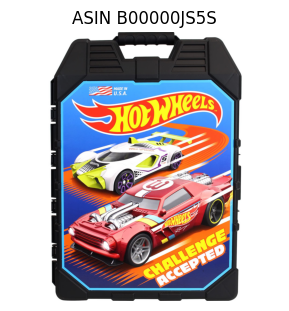

subcategory: Cars & Race Cars
rating: 4.6   reviews: 6403

description (800 characters):

Hot Wheels: 48 Cart Storage Case, Easy Grip Carrying Case, Makes Collecting and Clean Up Easy and Fun, Styles in Case May Vary, For Ages 3 and up | Cars & Race Cars | Product Description

Hot Wheels 48-car storage case w/easy grip carrying handle

From the Manufacturer

New graphic for 2006! Blue & Black Asst. Boys will have fun storing and showing off their favorite vehicles in this rugged plastic case. This carry case holds up to 48 - 1:64th scale vehicles. Note: Customer images may show outdated packaging and styles. | Conveniently store and carry up to 48 Hot Wheels cars | Makes collecting and clean up, easy and fun | Fits 1:64th scale cars, including most brands | Measures 13.3" x 10" x 3.7" | Kids ages 3 and up | Tara Toy | Hot Wheels | Toy | 20020 | Color: 48 Car;  | 48 Car | 48-car ...


In [5]:
# Lab 1 downloads a single image part-file and shows a product from it.
first_images = pd.read_parquet(fetch(image_files[0]))
example_asin = df.loc[df["ASIN"].isin(set(first_images["ASIN"])), "ASIN"].iloc[0]
example = df[df["ASIN"] == example_asin].iloc[0]

hit = first_images[first_images["ASIN"] == example_asin]
image = Image.open(io.BytesIO(hit["image"].iloc[0]["bytes"])).convert("RGB")
del first_images, hit

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.imshow(image)
ax.axis("off")
ax.set_title(f"ASIN {example_asin}")
plt.show()

print(f"subcategory: {example['subcat_aggregated']}")
print(f"rating: {example['RATING']:.1f}   reviews: {example['REVIEW_COUNT']:.0f}")
print()
print(f"description ({len(example['text'])} characters):")
print()
print(example["text"][:900] + " ...")

## Prices and Sales Ranks over Time

Next, we plot the price and quantity signals of two products over time. The solid line shows the 7-day average and the dashed line the 28-day average that we use in the labs.

Sales ranks move from week to week, whereas prices tend to stay at one value for several weeks and then jump. This asymmetry matters for the identification argument in Lab 4: if prices rarely move, they are unlikely to respond to short-run demand shocks.

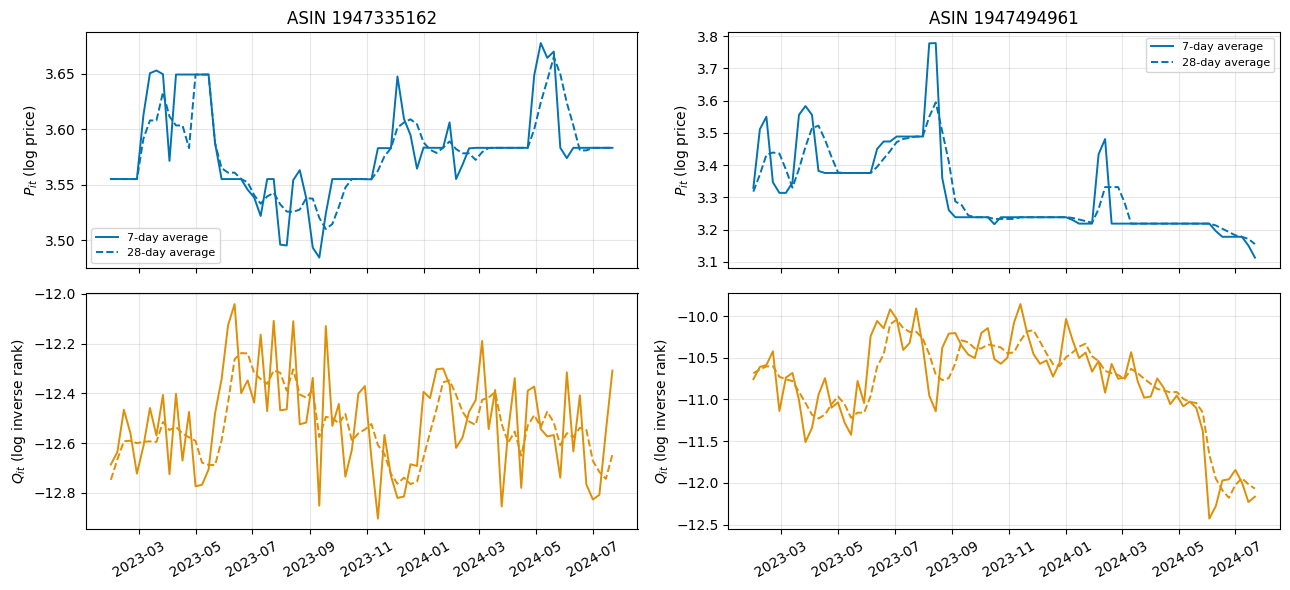

In [6]:
# two products that are observed in all 14 periods
n_obs = df.groupby("ASIN").size()
examples = n_obs[n_obs == 14].index[:2].tolist()

weekly = pd.concat([pd.read_parquet("data_cache/" + f.split("/")[-1],
                                    columns=["ASIN", "window", "date",
                                             "SALES_RANK", "BUYBOX_PRICE"])
                    for f in panel_files], ignore_index=True)
weekly = weekly[weekly["ASIN"].isin(examples)].copy()
weekly["date"] = pd.to_datetime(weekly["date"])
weekly = weekly.sort_values(["ASIN", "window", "date"])

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for j, asin in enumerate(examples):
    for i, (col, label) in enumerate([("BUYBOX_PRICE", "$P_{it}$ (log price)"),
                                      ("SALES_RANK", "$Q_{it}$ (log inverse rank)")]):
        ax = axes[i, j]
        for w, style in [(7, "-"), (28, "--")]:
            s = weekly[(weekly["ASIN"] == asin) & (weekly["window"] == w)]
            ax.plot(s["date"], s[col], style, color=palette[i], lw=1.4,
                    label=f"{w}-day average")
        ax.set_ylabel(label)
        ax.grid(alpha=0.3)
        if i == 0:
            ax.set_title(f"ASIN {asin}")
            ax.legend(fontsize=8)
for ax in axes[1]:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Descriptive Statistics

We now compute summary statistics for the price and quantity signals, the average rating and the number of reviews.

In [7]:
df[["Q_t", "P_bb_t", "RATING", "REVIEW_COUNT"]].describe().round(3)

,Q_t,P_bb_t,RATING,REVIEW_COUNT
count,83777.000,83777.000,83777.000,83777.000
mean,-11.108,3.035,4.495,864.069
std,1.309,0.623,0.360,2908.138
min,-14.230,0.531,1.000,-1.000
25%,-12.040,2.638,4.321,29.000
50%,-11.345,2.995,4.589,147.714
75%,-10.411,3.389,4.700,641.214
max,-2.691,7.473,5.000,100314.357


The histograms below show the distributions of the two signals across all product-periods.

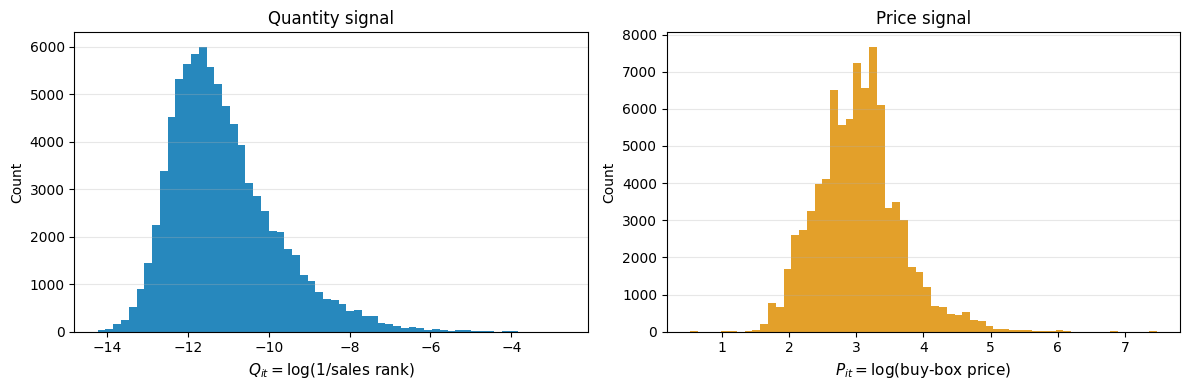

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Q_t"], bins=60, color=palette[0], alpha=0.85, edgecolor="none")
axes[0].set_xlabel("$Q_{it} = \\log(1/\\mathrm{sales\\ rank})$", fontsize=11)
axes[0].set_title("Quantity signal")

axes[1].hist(df["P_bb_t"], bins=60, color=palette[1], alpha=0.85, edgecolor="none")
axes[1].set_xlabel("$P_{it} = \\log(\\mathrm{buy\\text{-}box\\ price})$", fontsize=11)
axes[1].set_title("Price signal")

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Finally, we count the number of products in each subcategory.

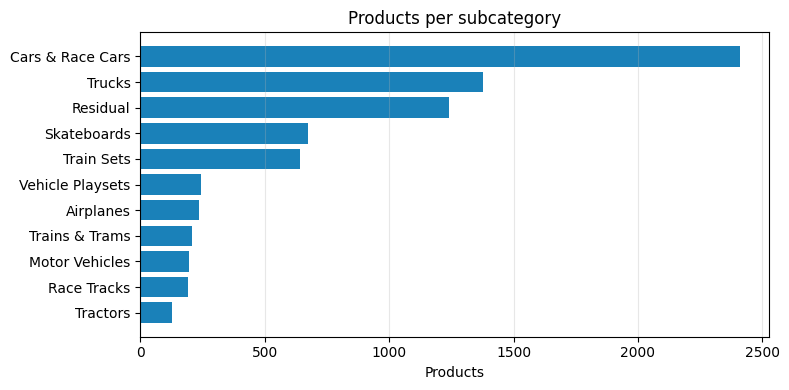

In [9]:
counts = df.groupby("subcat_aggregated")["ASIN"].nunique().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(counts.index, counts.values, color=palette[0], alpha=0.9)
ax.set_xlabel("Products")
ax.set_title("Products per subcategory")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Levels versus Changes

So far, we have looked at the levels of the two signals. The following histograms show their period-to-period changes, $\Delta Q_{it}$ and $\Delta P_{it}$. We also print the standard deviations of levels and changes and the share of product-periods in which the price does not change at all.

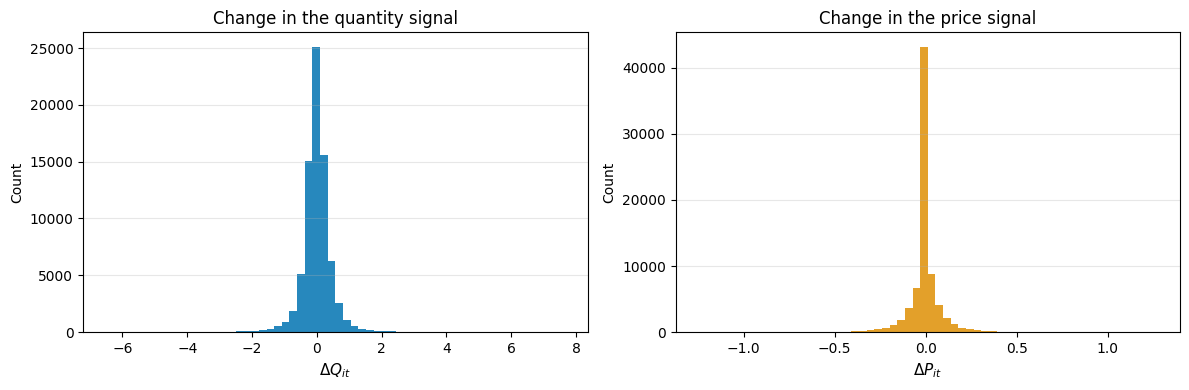

Q_t             1.309
P_bb_t          0.623
Delta_Q_t       0.459
Delta_P_bb_t    0.090

share of periods with an exactly unchanged price: 35.1%


In [10]:
chg = df.dropna(subset=["Delta_Q_t", "Delta_P_bb_t"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(chg["Delta_Q_t"], bins=60, color=palette[0], alpha=0.85, edgecolor="none")
axes[0].set_xlabel("$\\Delta Q_{it}$", fontsize=11)
axes[0].set_title("Change in the quantity signal")

axes[1].hist(chg["Delta_P_bb_t"], bins=60, color=palette[1], alpha=0.85, edgecolor="none")
axes[1].set_xlabel("$\\Delta P_{it}$", fontsize=11)
axes[1].set_title("Change in the price signal")

for ax in axes:
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(chg[["Q_t", "P_bb_t", "Delta_Q_t", "Delta_P_bb_t"]].std().round(3).to_string())
print(f"\nshare of periods with an exactly unchanged price: "
      f"{(chg['Delta_P_bb_t'].abs() < 1e-8).mean():.1%}")

The changes are much less dispersed than the levels. The standard deviation of the price signal is roughly seven times larger in levels than in changes, where it is only about 0.09, and in about 35% of all product-periods the price does not change at all. Prices are thus sticky.

Product characteristics can explain a good deal of why one product is more expensive than another, but little about why the price of a given product changes in a given period. Lab 3 quantifies this difference, and Labs 4 and 5 build on it.

## A Naive Estimate of the Price Elasticity

A natural first step is to regress the quantity signal on the price signal,
$$Q_{it} = \delta P_{it} + g_t(X_{it}) + \epsilon_{it},$$
where $X_{it}$ denotes observed product characteristics. We use the estimation sample $I_2$ (37,940 observations) and first estimate the regression without controls, so that $g_t(X_{it})$ reduces to a constant. Standard errors are clustered at the product level.

In [11]:
# the estimation sample I_2
est = df[(df["split"] == "estimation") & df["in_sample"]]

naive = sm.OLS(est["Q_t"], sm.add_constant(est["P_bb_t"])).fit(
    cov_type="cluster", cov_kwds={"groups": est["ASIN"]})
print(naive.summary().tables[1])
print(f"\nimplied demand elasticity (x2): {2 * naive.params['P_bb_t']:.3f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.8933      0.104   -104.291      0.000     -11.098     -10.689
P_bb_t        -0.0800      0.034     -2.384      0.017      -0.146      -0.014

implied demand elasticity (x2): -0.160


The estimated coefficient, $-0.080$, is small and negative; on its estimation sample, the paper obtains $-0.111$. Next, we add the tabular controls: the average rating, the number of reviews and subcategory dummies.

In [12]:
X = sm.add_constant(est[["P_bb_t", "RATING", "REVIEW_COUNT"]])
X = pd.concat(
    [X, pd.get_dummies(est["subcat_aggregated"], prefix="sub", drop_first=True).astype(int)],
    axis=1)

controlled = sm.OLS(est["Q_t"], X).fit(
    cov_type="cluster", cov_kwds={"groups": est["ASIN"]})
print(controlled.summary().tables[1].as_text()[:1400])
print(f"\ndelta = {controlled.params['P_bb_t']:.3f}   "
      f"implied demand elasticity (x2): {2 * controlled.params['P_bb_t']:.3f}")

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -10.8904      0.259    -42.115      0.000     -11.397     -10.384
P_bb_t                  -0.1966      0.030     -6.449      0.000      -0.256      -0.137
RATING                   0.0829      0.048      1.715      0.086      -0.012       0.178
REVIEW_COUNT             0.0003   1.66e-05     16.878      0.000       0.000       0.000
sub_Cars & Race Cars    -0.2606      0.119     -2.199      0.028      -0.493      -0.028
sub_Motor Vehicles       0.0172      0.161      0.107      0.915      -0.299       0.333
sub_Race Tracks         -0.0171      0.172     -0.099      0.921      -0.355       0.320
sub_Residual            -0.4853      0.122     -3.980      0.000      -0.724      -0.246
sub_Skateboards         -0.5304      0.124     -4.289      0.000      -0.773      -0.288
sub_Tractors         

## Discussion

Both regressions yield estimates of $\delta$ between about $-0.2$ and $-0.08$, close to the range of $[-0.3, -0.1]$ that the paper reports for such regressions. After the Pareto conversion, this implies that a 1% price increase reduces units sold by only a few tenths of a percent. Such inelastic demand would allow sellers to raise prices almost without losing sales, which is not credible for toy cars on a marketplace where close substitutes are one click away.

The problem is omitted variable bias. Popular, high-quality and highly visible products sell more and, at the same time, can sustain higher prices. This common driver biases $\hat\delta$ toward zero. Correcting the bias requires measures of product quality and visibility, but neither is a column in the data. Both are latent, and the closest measurements we have are the product description and the product image.

The remaining labs build on this observation:

* **Lab 2** maps descriptions and images into embeddings that are fine-tuned to predict price and quantity.
* **Lab 3** measures how much these embeddings help to predict $Q$, $P$, $\Delta Q$ and $\Delta P$.
* **Lab 4** estimates the average price elasticity by double machine learning, using lagged quantity and price as state variables that capture visibility and quality.
* **Lab 5** allows the price elasticity to vary across products.